In [13]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.e import Model_e
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [156]:
a = Model_e()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

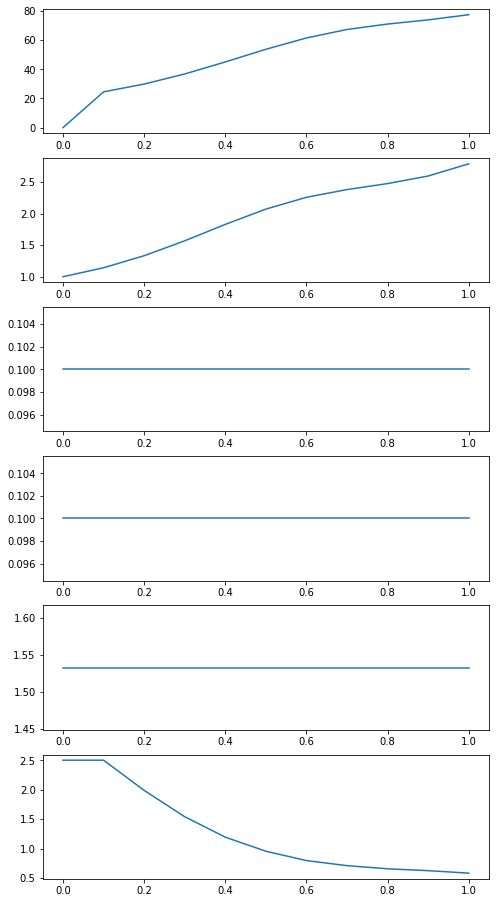

In [157]:
dur = 1.

a.params.duration = dur

target = a.getZeroTarget()
control1 = a.getZeroControl()
a.params.ext_exc_current = 3.

control1[0,0,:] += 1.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.rates_exc[:,:]

fig, axes = plt.subplots(6, figsize=(8, 16))
axes[0].plot(a.t, a.state["rates_exc"][0,:])
axes[1].plot(a.t, a.state["mufe"][0,:])
axes[2].plot(a.t, a.state["seem"][0,:])
axes[3].plot(a.t, a.state["seev"][0,:])
axes[4].plot(a.t, a.state["sigmae_f"][0,:])
axes[5].plot(a.t, a.state["tau_exc"][0,:])

In [158]:
max_cntrl = 10. * 5.
start_step = 13.0
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init, a.params.seem_init, a.params.seev_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 1.

max_it = 100

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

#0.7262797905237487

set cost params
RUN  0 , total integrated cost =  123.99469335214452
RUN  1 , total integrated cost =  5.763752658697123
RUN  2 , total integrated cost =  2.2336947788370667
RUN  3 , total integrated cost =  1.650725701460098
RUN  4 , total integrated cost =  1.5578282700012607
RUN  5 , total integrated cost =  1.5033132057463439
RUN  6 , total integrated cost =  1.4843300775163875
RUN  7 , total integrated cost =  1.4657888569606443
RUN  8 , total integrated cost =  1.4581400029111935
RUN  9 , total integrated cost =  1.4461080873572885
RUN  10 , total integrated cost =  1.4407944004516189
RUN  11 , total integrated cost =  1.4246600126232751
RUN  12 , total integrated cost =  1.4246581315434488
RUN  13 , total integrated cost =  1.424658131543448
RUN  14 , total integrated cost =  1.4246581315434477
State only changes marginally.
Improved over  14  iterations by  98.85103298130879  percent.
final gradient =  [[[0.         0.67610272 0.46165983 0.27709825 0.30343481 0.37254598
   0.16

[[[0.         1.64527054 1.77786987 1.83595343 1.65970406 1.19217928
   0.61620999 0.1633263  0.03322602 0.19510319 0.        ]]]


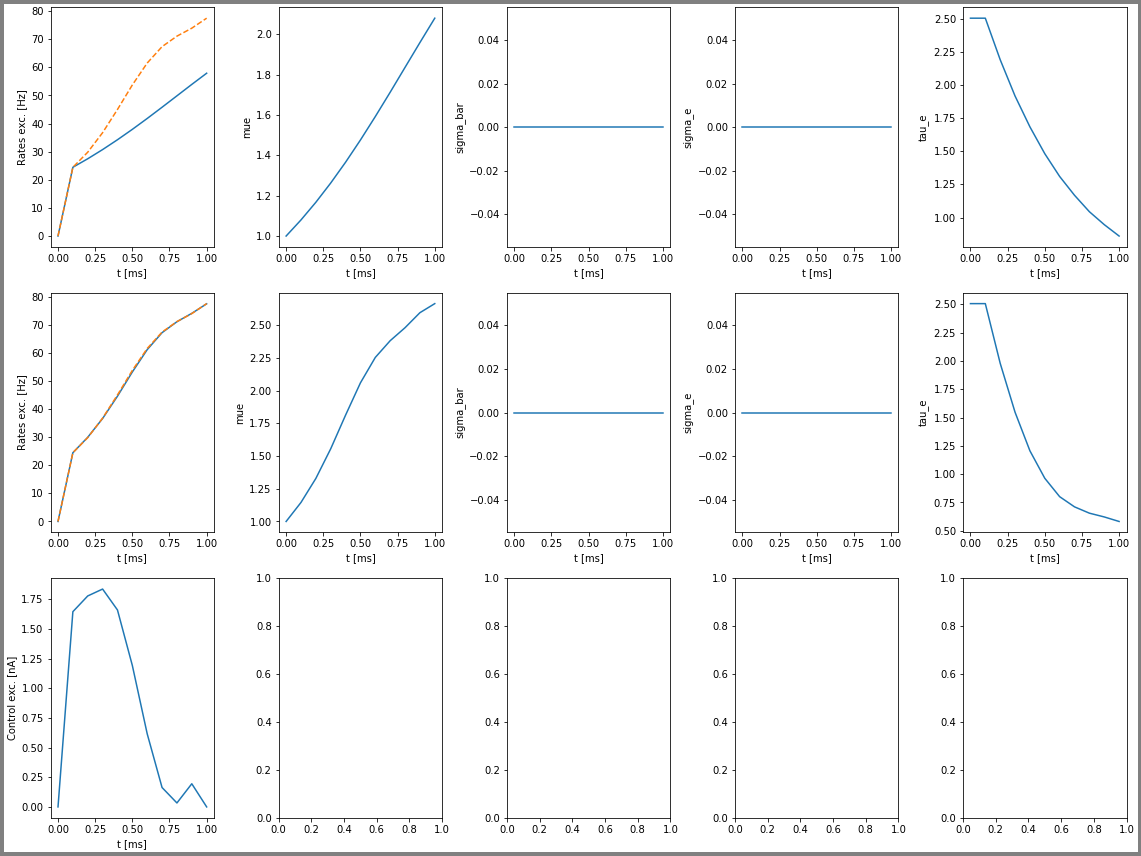

In [60]:
#1.4254799807322216
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [159]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 60

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  123.99469335214452
RUN  1 , total integrated cost:  21.970636588451672
RUN  2 , total integrated cost:  8.793992859095622
RUN  3 , total integrated cost:  4.3782540030800305
RUN  4 , total integrated cost:  2.7040819946643686
RUN  5 , total integrated cost:  1.9940669747996216
RUN  6 , total integrated cost:  1.6822647815774445
RUN  7 , total integrated cost:  1.5489153554306156
RUN  8 , total integrated cost:  1.4922648465300834
RUN  9 , total integrated cost:  1.4684800392310888
RUN  10 , total integrated cost:  1.458067482975927
RUN  11 , total integrated cost:  1.452610205733993
RUN  12 , total integrated cost:  1.4480092892312884
change helped, counter =  3
RUN  13 , total integrated cost:  1.4438291082006705
RUN  14 , total integrated cost:  1.4399544416088044
change helped, counter =  2
RUN  15 , total integrated cost:  1.4364550202583233
change helped, counter =  2
RUN  16 , total integrated cost:  1.433415851999759
change helped,

[[[0.         1.94740326 1.98291347 1.98900877 2.01736511 1.97428606
   2.0060062  2.00721042 1.9916696  1.87240644 0.        ]]]


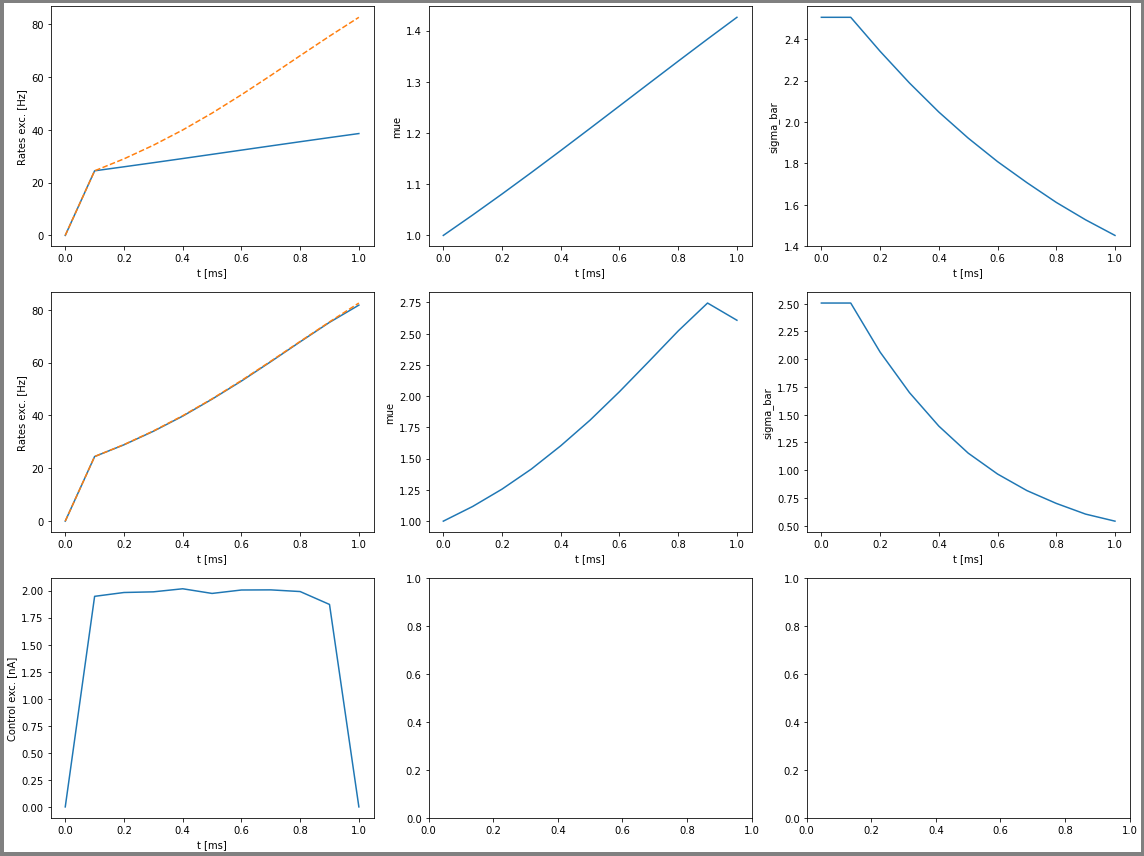

In [72]:
# 1.4231896066245588
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

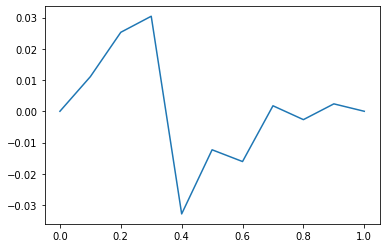

In [62]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

In [101]:
gradient_r = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))
gradient_sigma = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        res1 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1

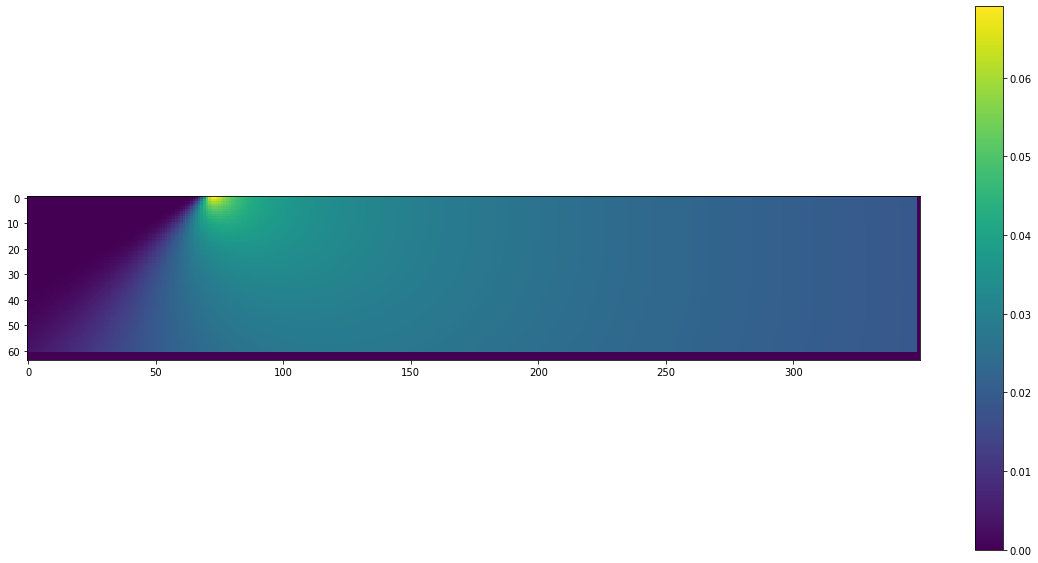

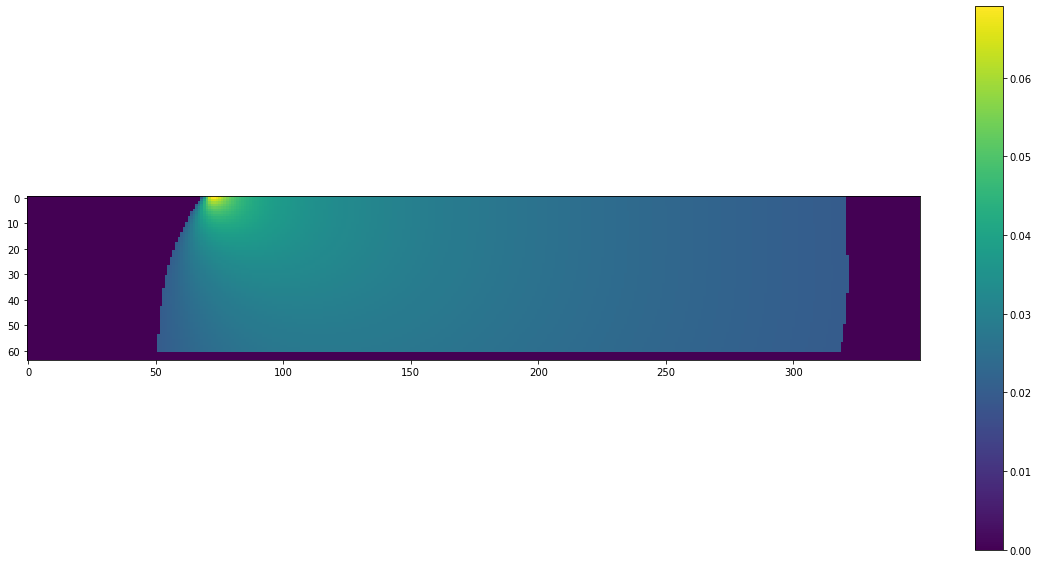

In [102]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()

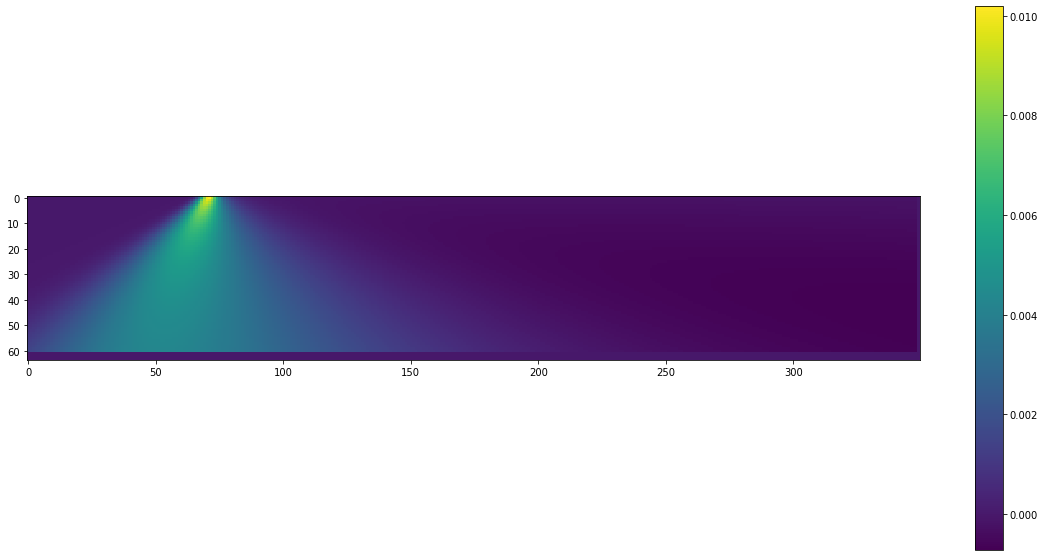

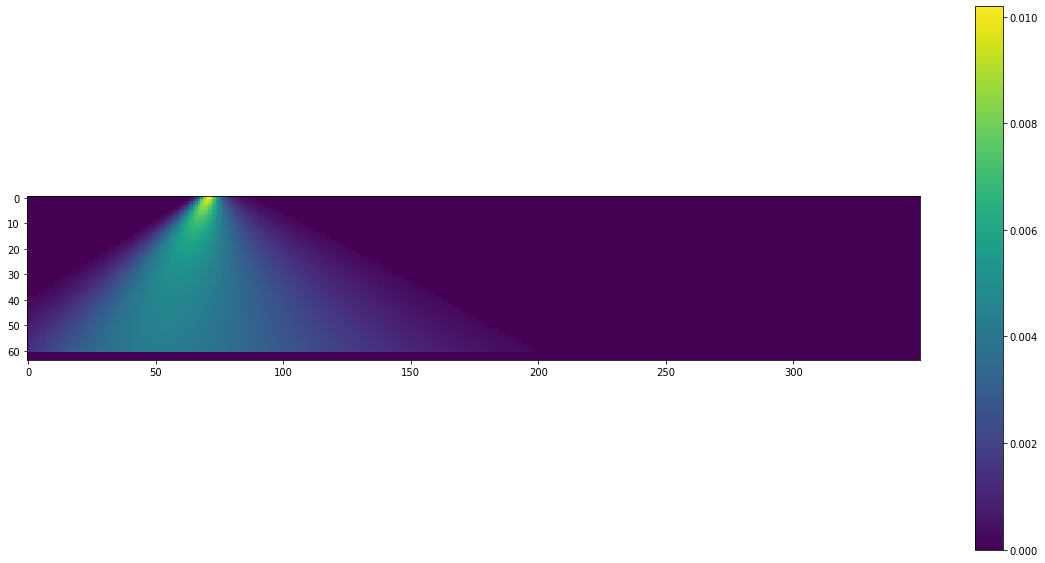

In [109]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,1].T)
plt.colorbar()
plt.show()

threshold = 0.0002
large_g_sigma = gradient_r.copy()
large_g_sigma[large_g_sigma < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g_sigma[:,:,1].T)
plt.colorbar()
plt.show()

In [122]:
gradient_tau = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))
gradient_sigma = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        res1 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        gradient_tau[mu, sigma, 0] = res0
        gradient_tau[mu, sigma, 1] = res1

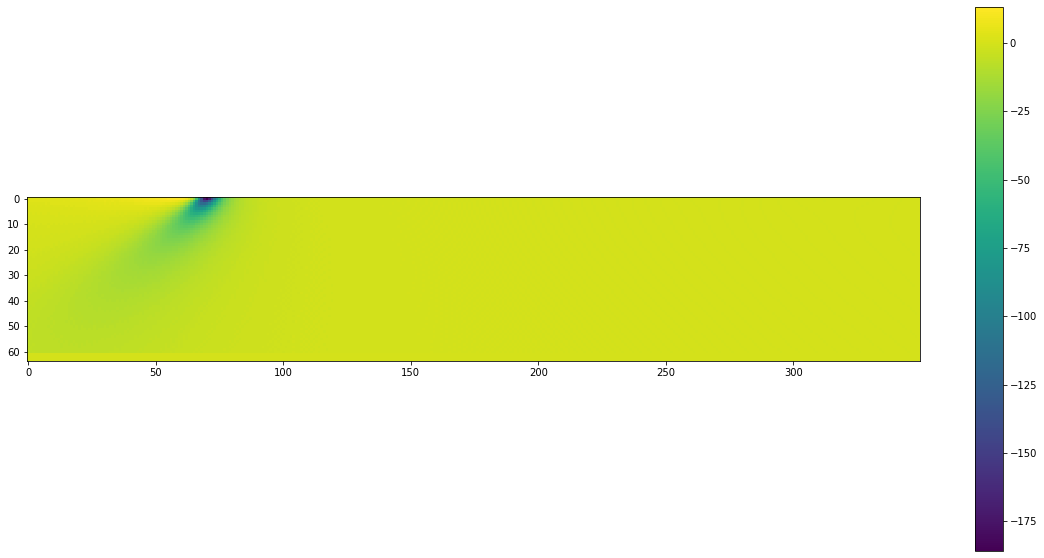

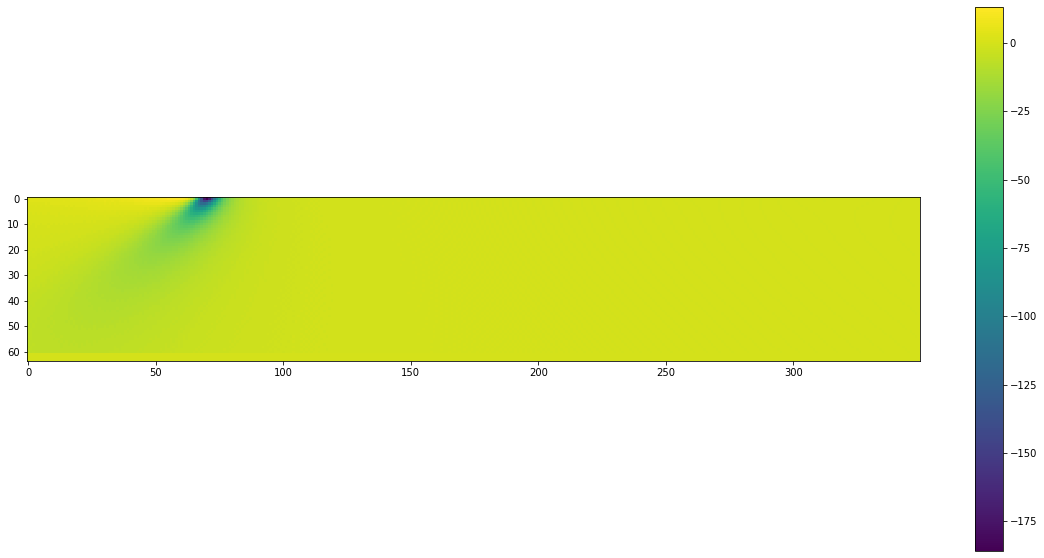

In [124]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_tau[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_tau.copy()
large_g[np.abs(large_g) < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()

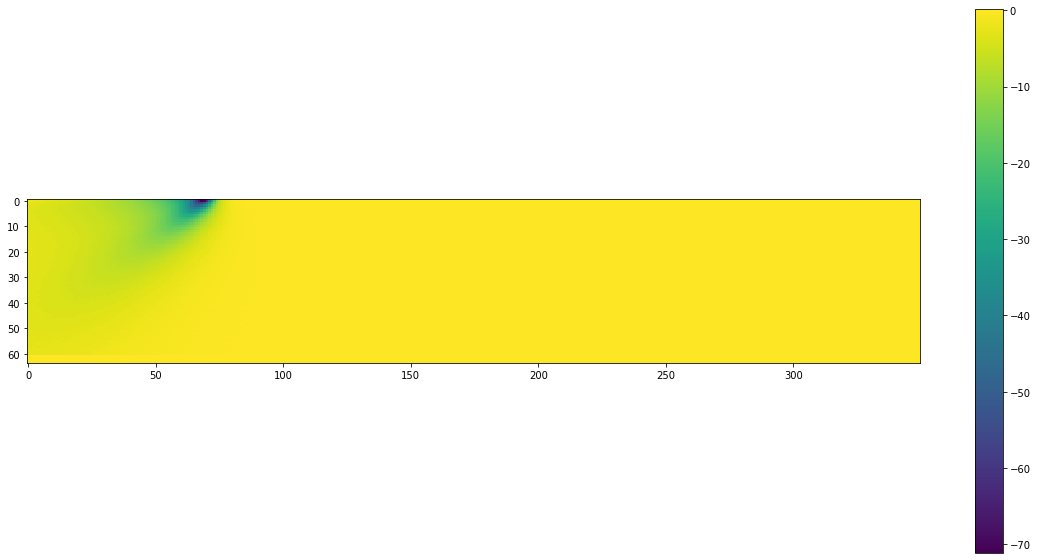

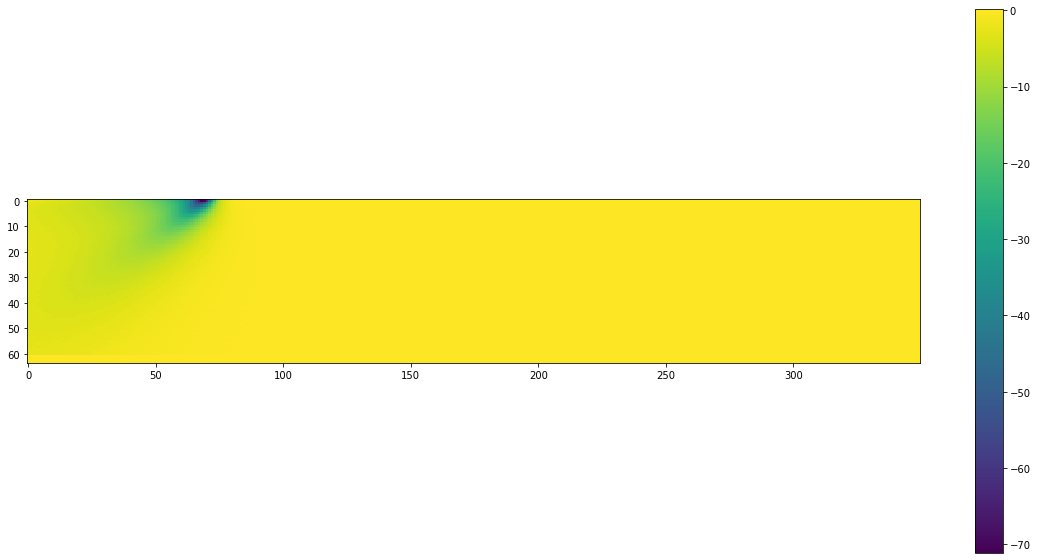

In [125]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_tau[:,:,1].T)
plt.colorbar()
plt.show()

threshold = 0.0002
large_g_sigma = gradient_tau.copy()
large_g_sigma[np.abs(large_g_sigma) < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g_sigma[:,:,1].T)
plt.colorbar()
plt.show()